# TEST: sintetizzazione di spettri lock-in 

In [1]:
import numpy as np

s = np.load('../data/test/X_spectra.npy')
B = np.load('../data/test/Y_B_field.npy')

In [2]:
f = np.arange(2500, 3250)
x_axis = range(2500, 3250)
ds_dx_post = np.zeros_like(s)
N_spettri = s.shape[0]
N_punti = s.shape[1]

NameError: name 'k' is not defined

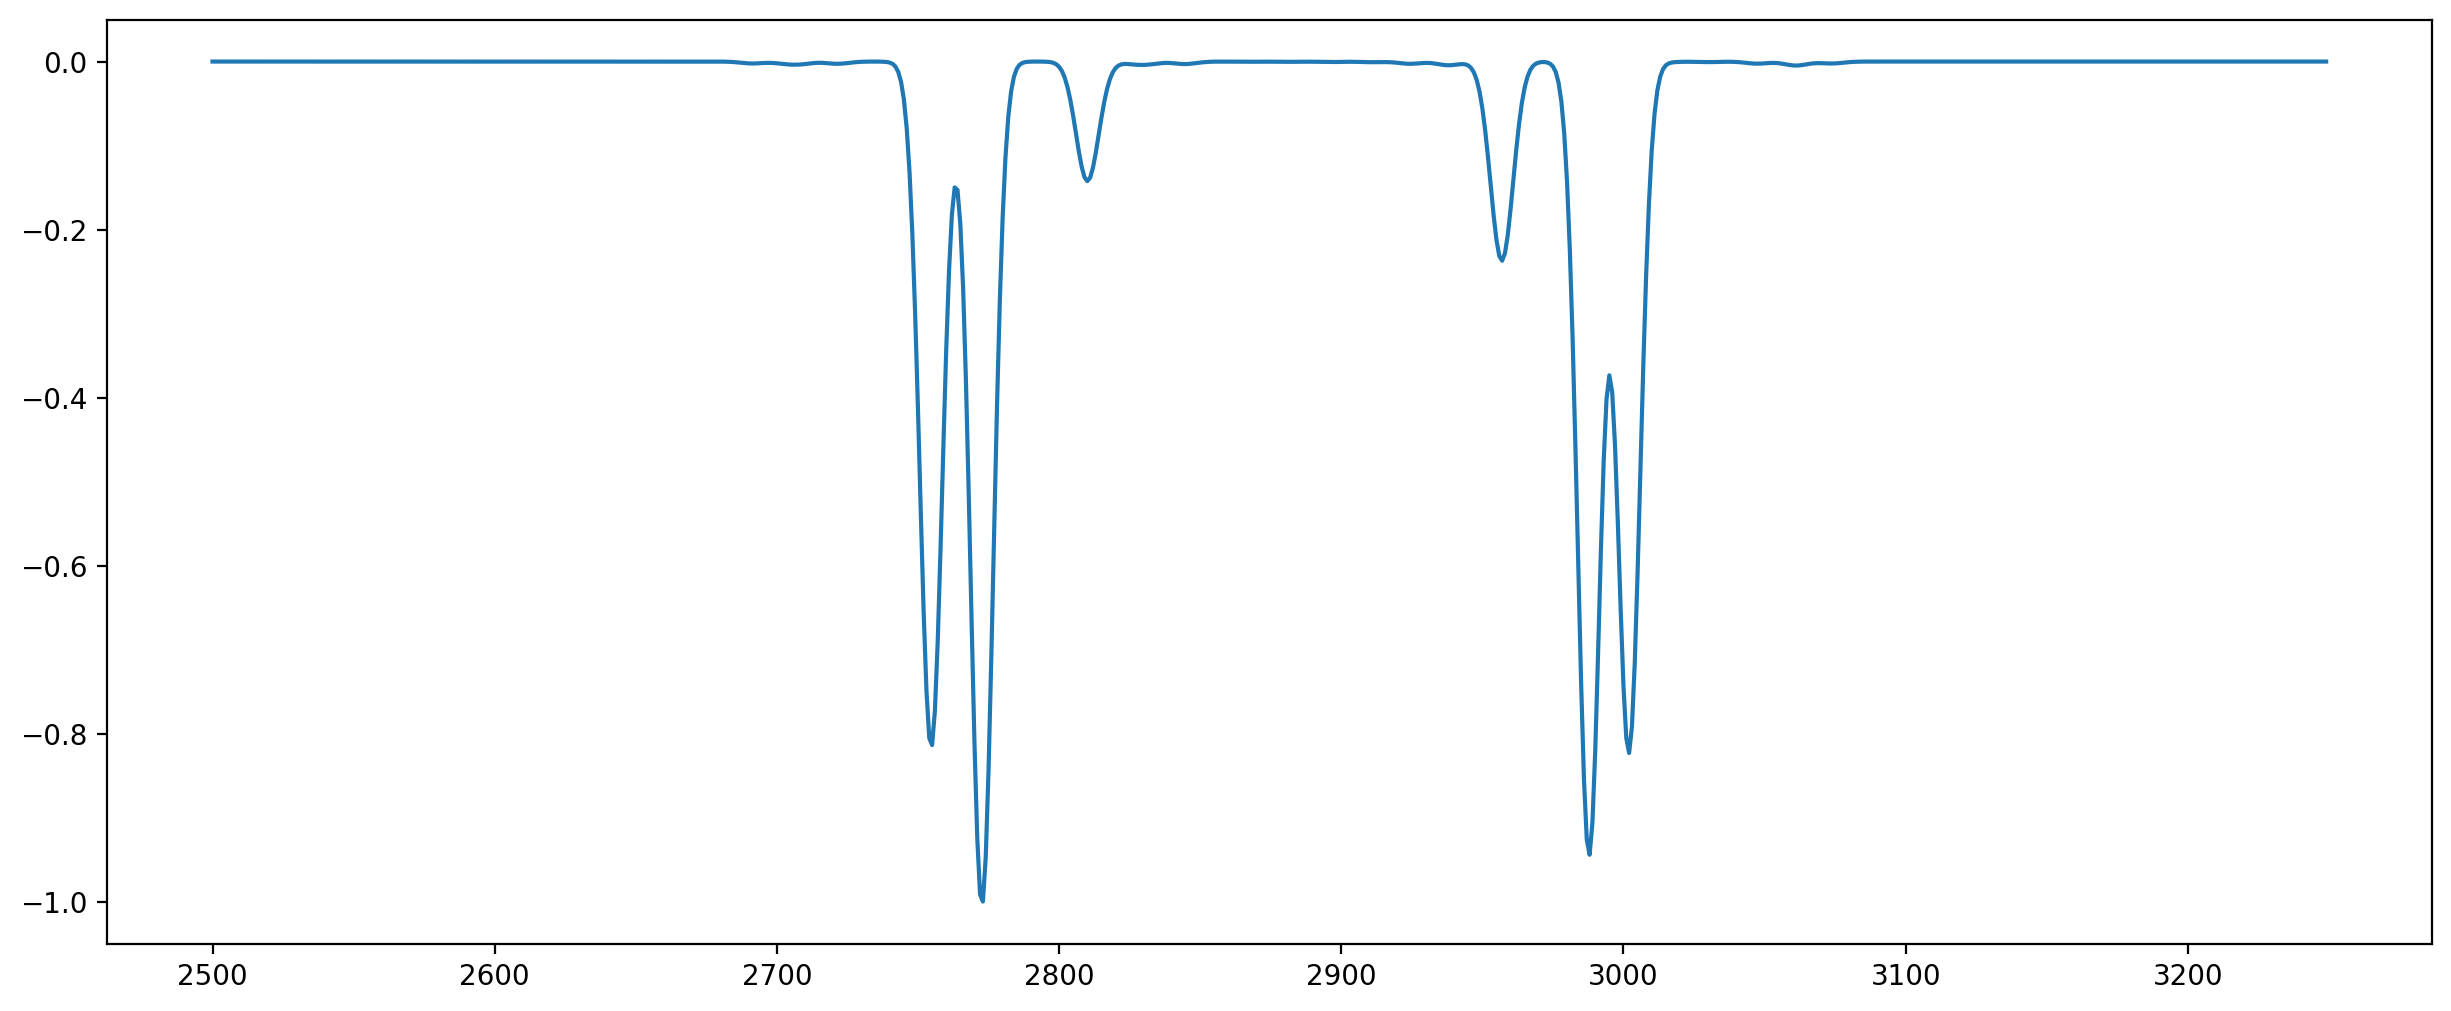

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[15])
plt.title(f"B={B[k]}")
plt.show()

#### derivata

In [ ]:
for i in range(N_spettri):
    ds_dx_post[i] = np.gradient(s[i], x_axis)
    for j in range(N_punti//2, N_punti):
        ds_dx_post[i][j] = -ds_dx_post[i][j]

#### inversione post-metà

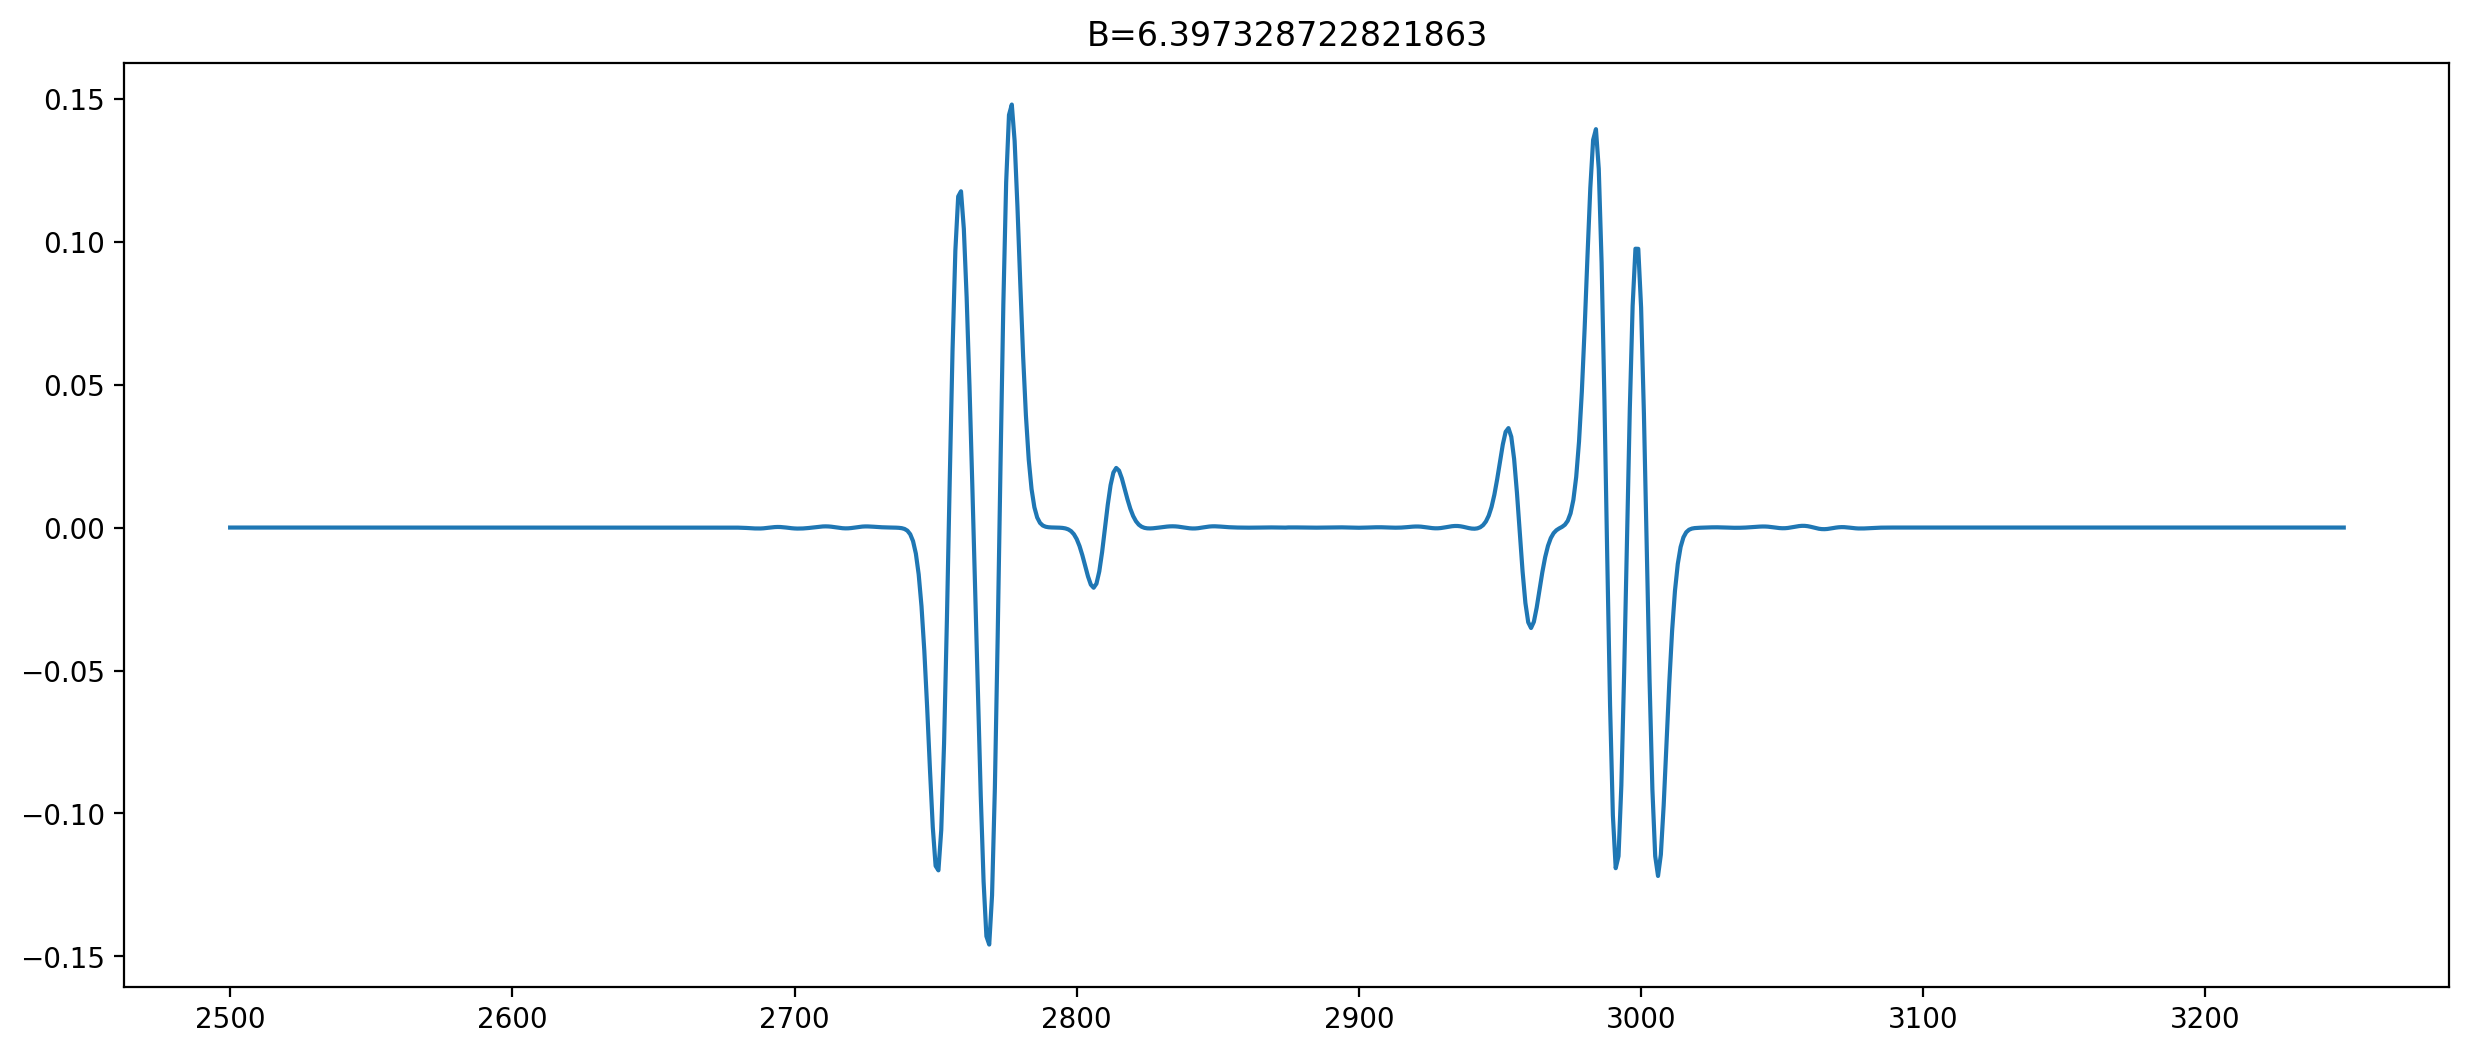

In [3]:
import matplotlib.pyplot as plt

k=15
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_dx_post[k])
plt.title(f"B={B[k]}")
plt.show()

## Noise dopo derivata

In [4]:
from ml_odmr.noising import *

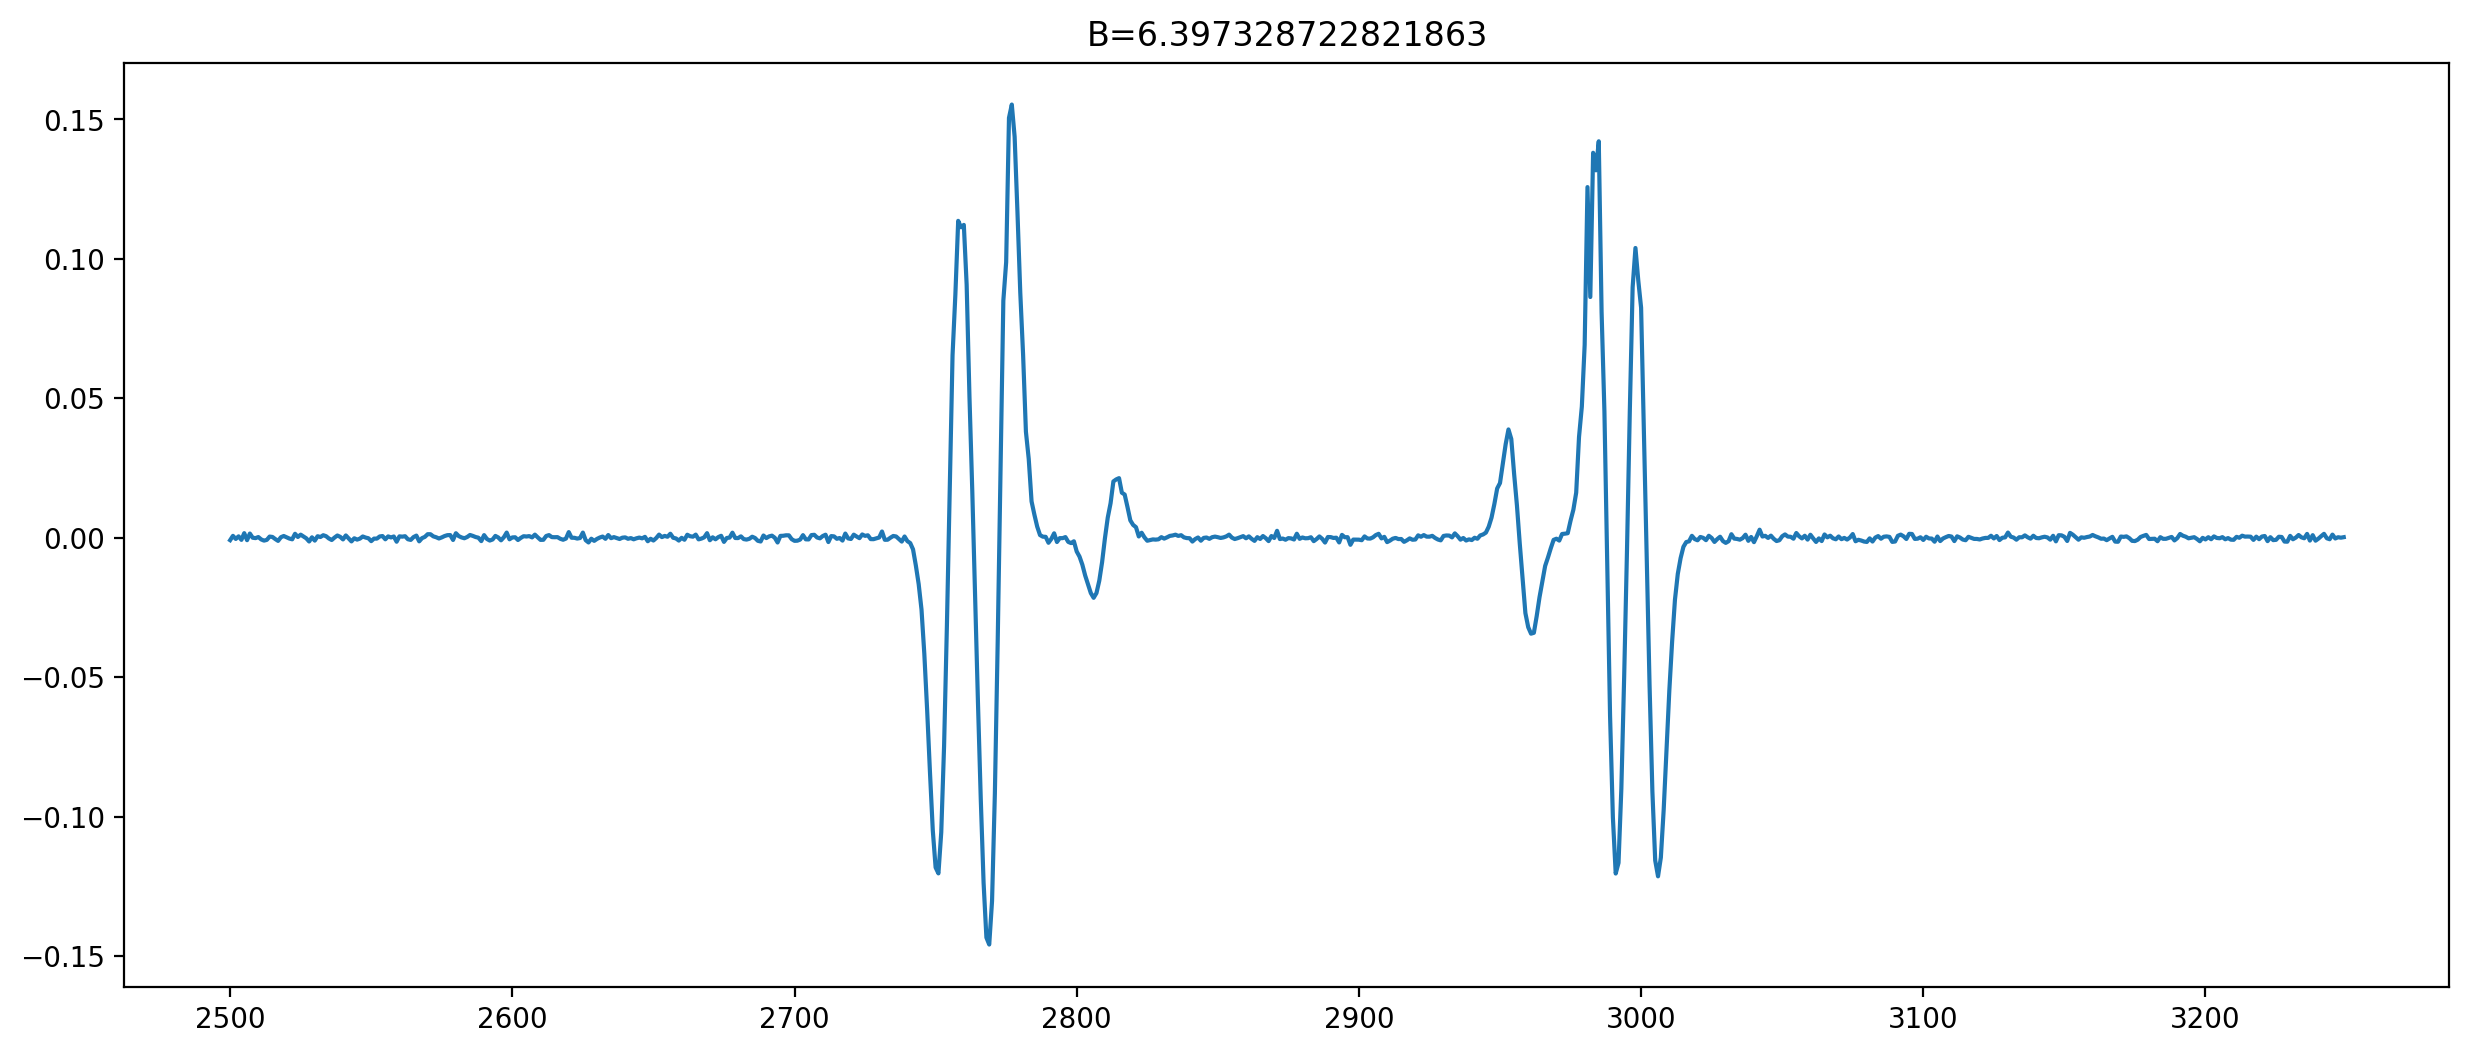

In [5]:
ds_dx_post_noisy = np.zeros_like(ds_dx_post)

for i in range(N_spettri):
    ds_dx_post_noisy[i] = add_poisson_noise(ds_dx_post[i], scale=0.1)

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_dx_post_noisy[k])
plt.title(f"B={B[k]}")
plt.show()

## Noise prima della derivata

In [6]:
s_noisy = np.zeros_like(s)
ds_dx_pre = np.zeros_like(s)
ds_dx_pre_noisy = np.zeros_like(s)

for i in range(N_spettri):
    # sporco s
    s_noisy[i] = add_poisson_noise(s[i], scale=0.05)
    s_noisy[i] = add_poly_trend(f, s_noisy[i], scale=0.5)

    # calcolo ds/dx sullo spettro sporco
    ds_dx_pre[i] = np.gradient(s_noisy[i], x_axis)
    for j in range(N_punti//2, N_punti):
        ds_dx_pre[i][j] = -ds_dx_pre[i][j]
        
    #ds_dx_pre_noisy[i] = add_poisson_noise(ds_dx_pre[i], scale=0.1)

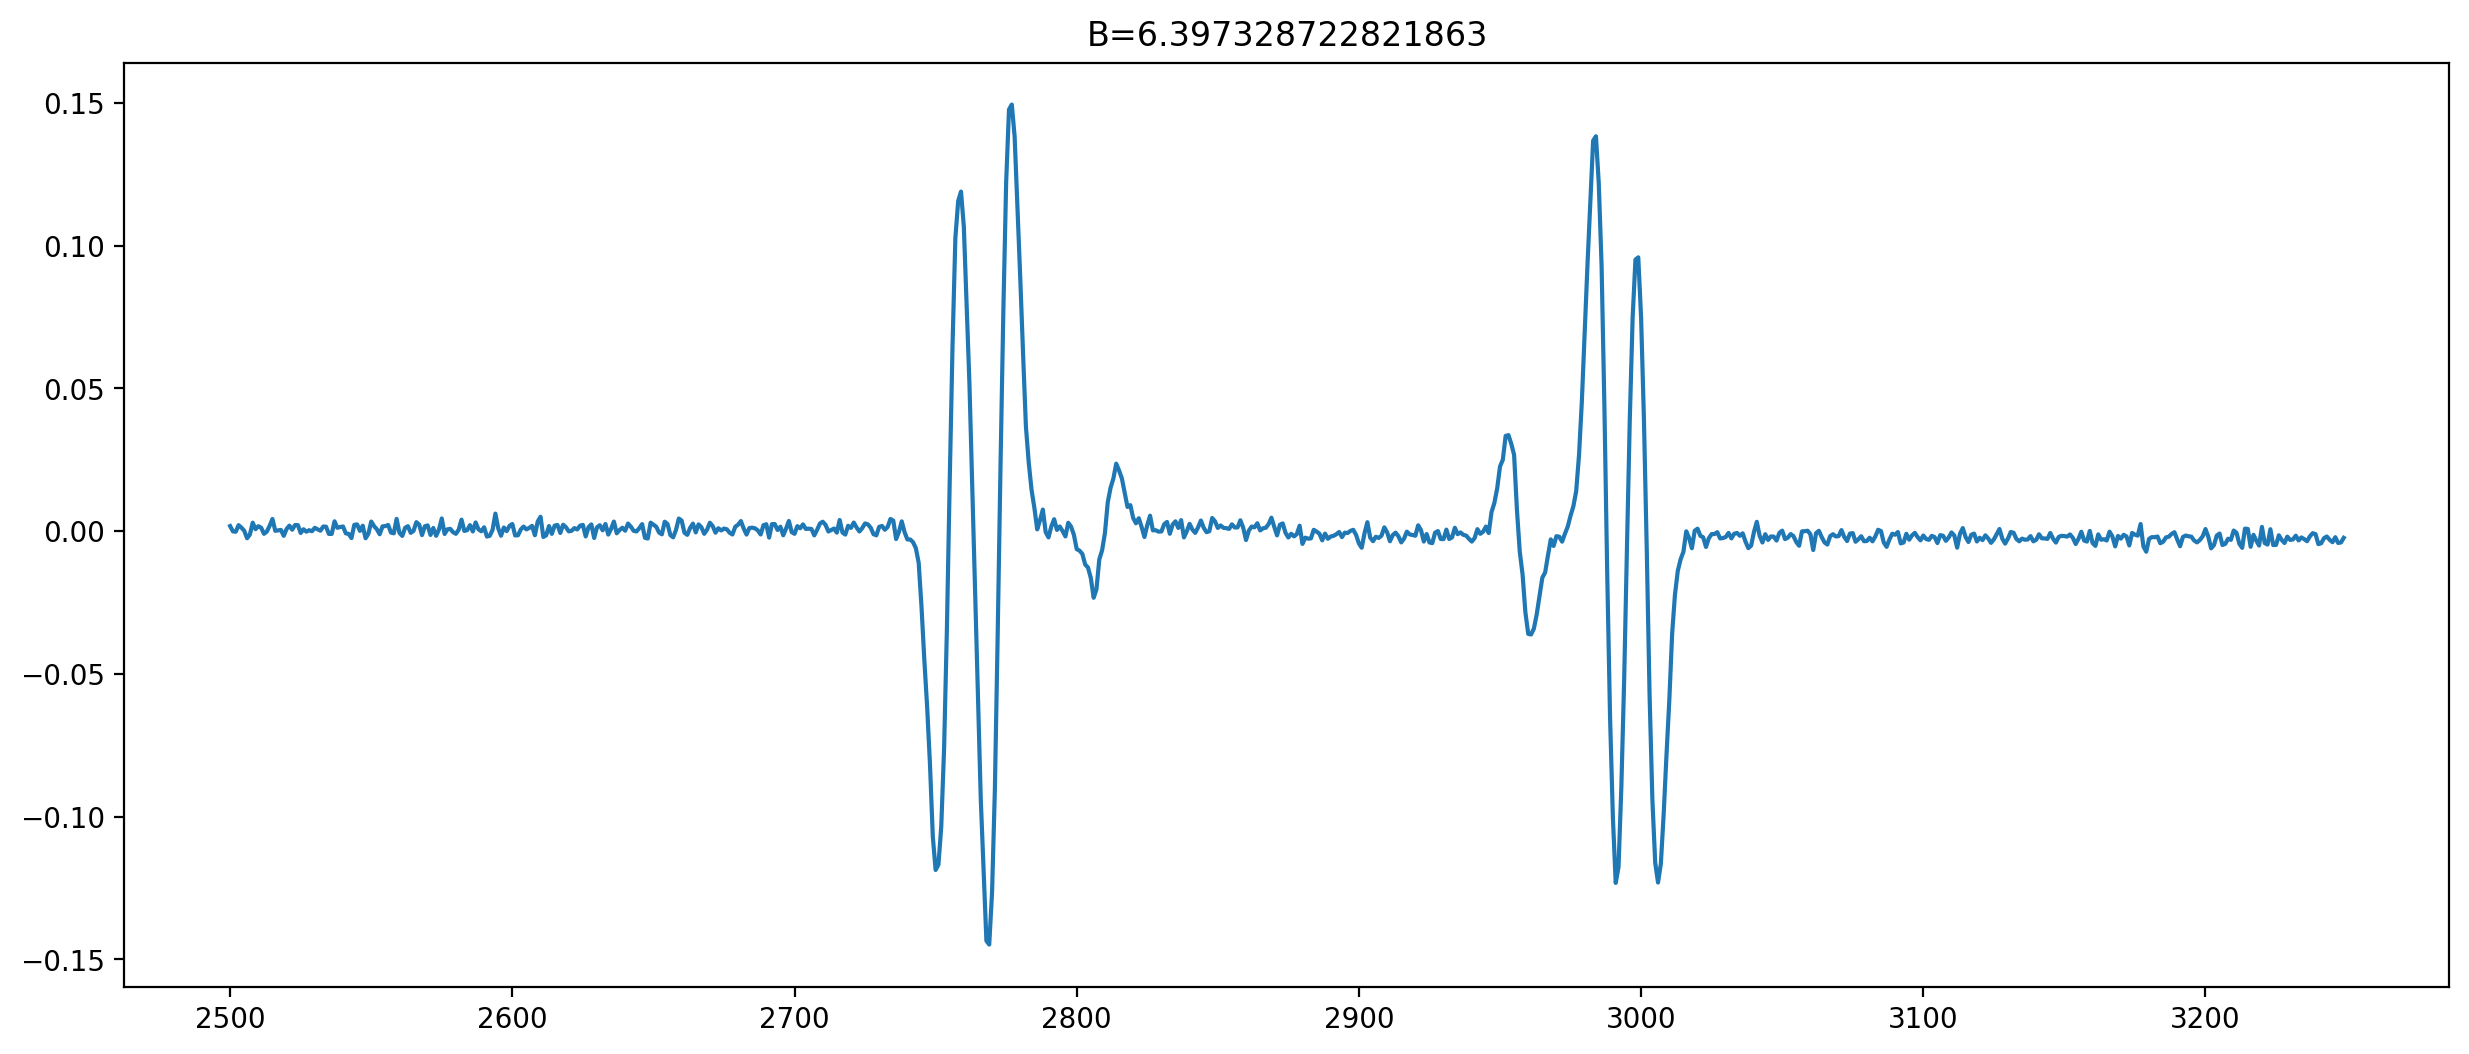

In [7]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_dx_pre[k])
plt.title(f"B={B[k]}")
plt.show()

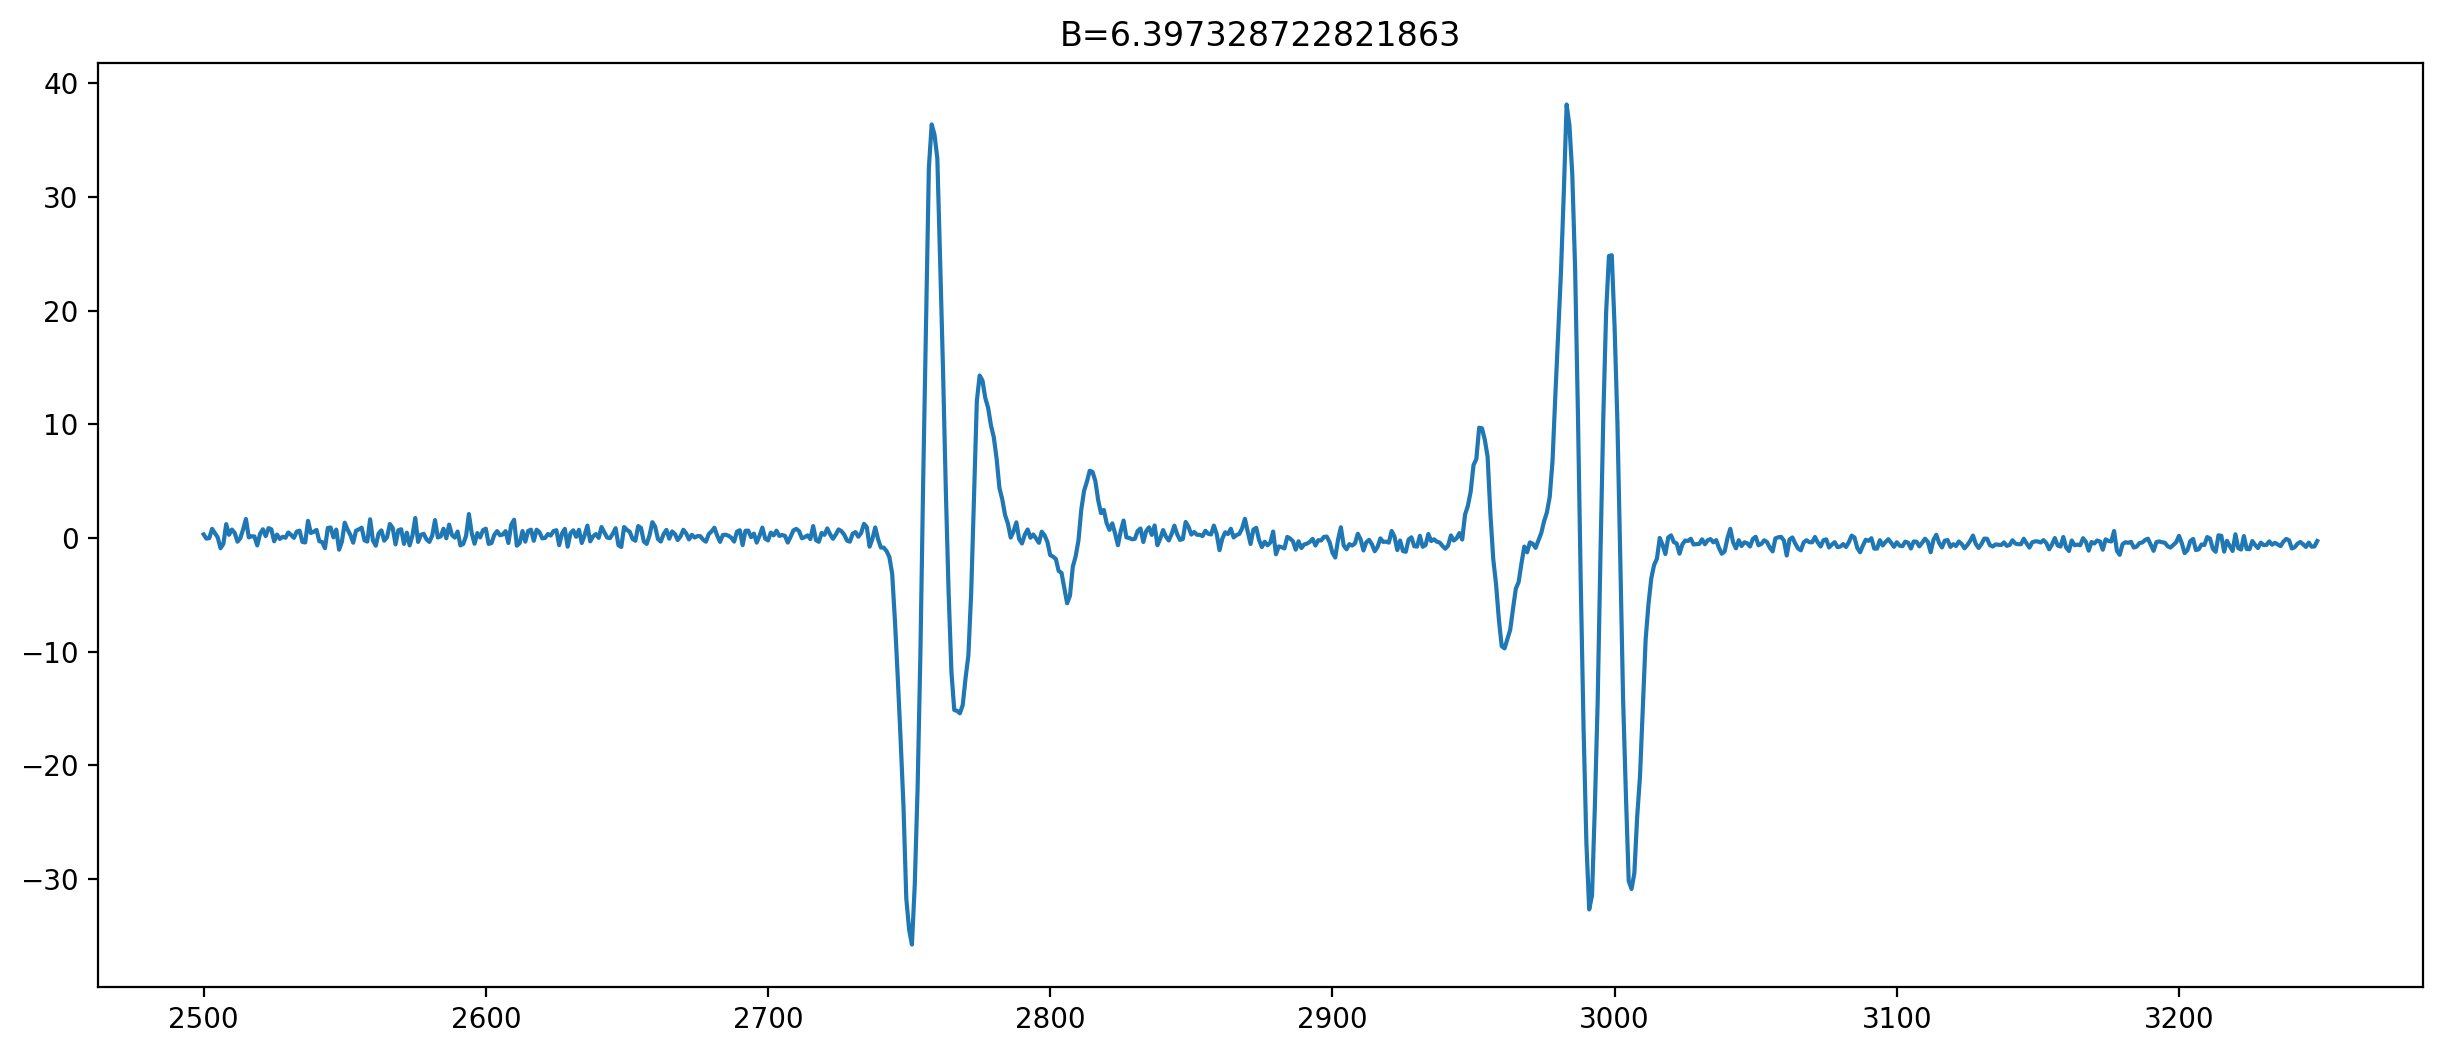

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler = RobustScaler()
ds_dx_pre_scaled = scaler.fit_transform(ds_dx_pre)

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_dx_pre_scaled[k])
plt.title(f"B={B[k]}")
plt.show()

### Ma un Savitzky-Golay come se la cava?

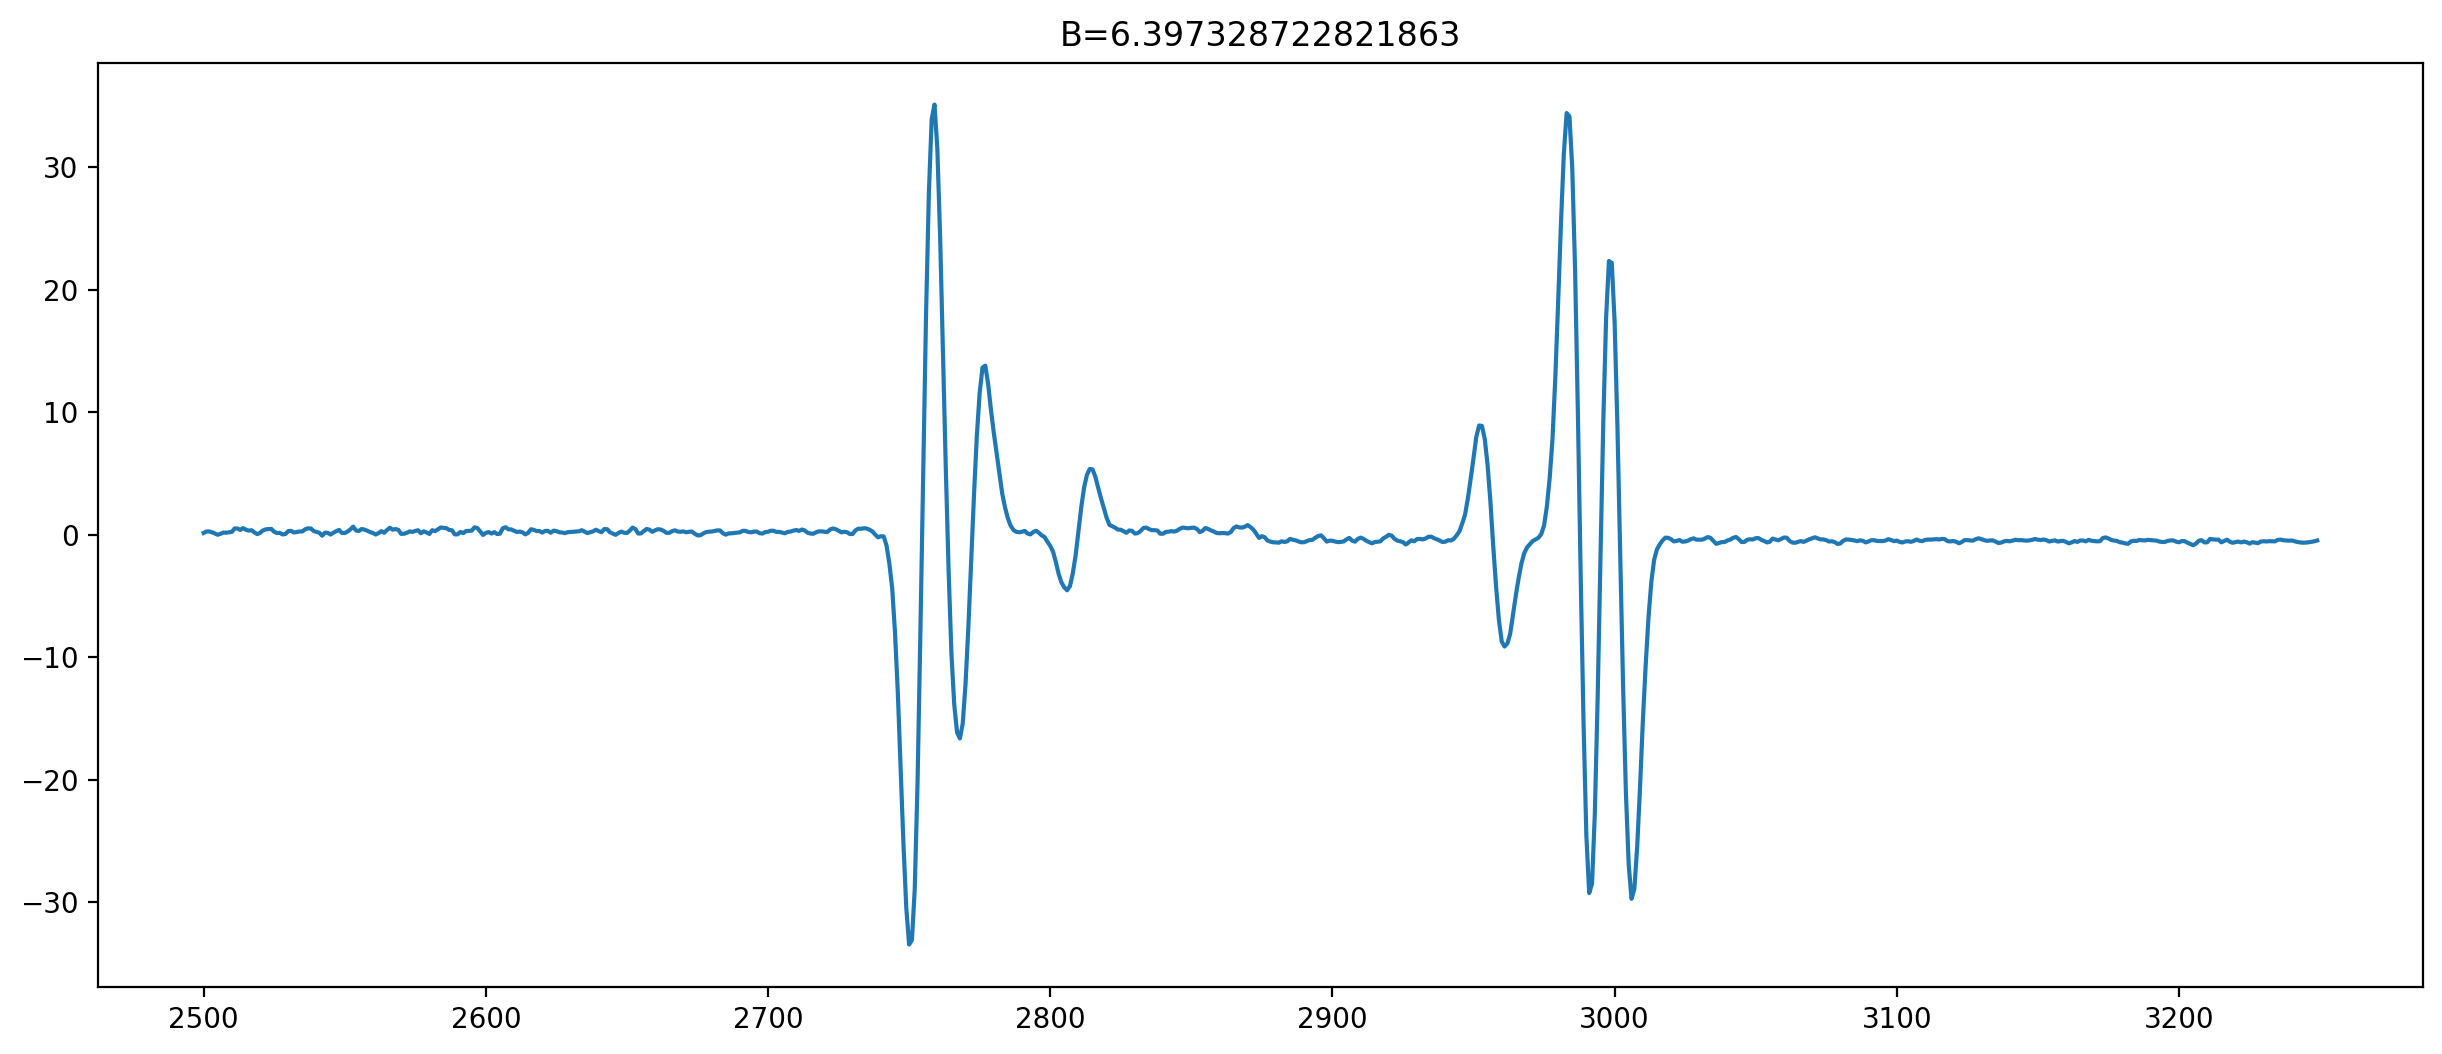

In [9]:
from scipy.signal import savgol_filter

ds_dx_pre_smoothed = savgol_filter(ds_dx_pre_scaled, window_length=11, polyorder=3, axis=1)

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_dx_pre_smoothed[k])
plt.title(f"B={B[k]}")
plt.show()